# 02 — Exploratory Data Analysis

A visual tour of the cleaned TMDB 5000 dataset: genre distribution, the most prolific actors and
directors, rating and runtime patterns, and release-year trends. Each chart is followed by a short,
data-driven takeaway computed directly from the dataframe.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import plotly.express as px
from collections import Counter

warnings_off = pd.options.mode.chained_assignment = None
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.facecolor"] = "#0e1117"
plt.rcParams["figure.facecolor"] = "#0e1117"
plt.rcParams["text.color"] = "#e6e6e6"
plt.rcParams["axes.labelcolor"] = "#e6e6e6"
plt.rcParams["xtick.color"] = "#cccccc"
plt.rcParams["ytick.color"] = "#cccccc"
ACCENT = "#6C63FF"

df = pd.read_csv("../data/processed_movies.csv")
for col in ["genres_list", "keywords_list", "cast_list", "production_companies_list"]:
    df[col] = df[col].apply(ast.literal_eval)

df.shape


(4799, 15)

## 1. Top Genres

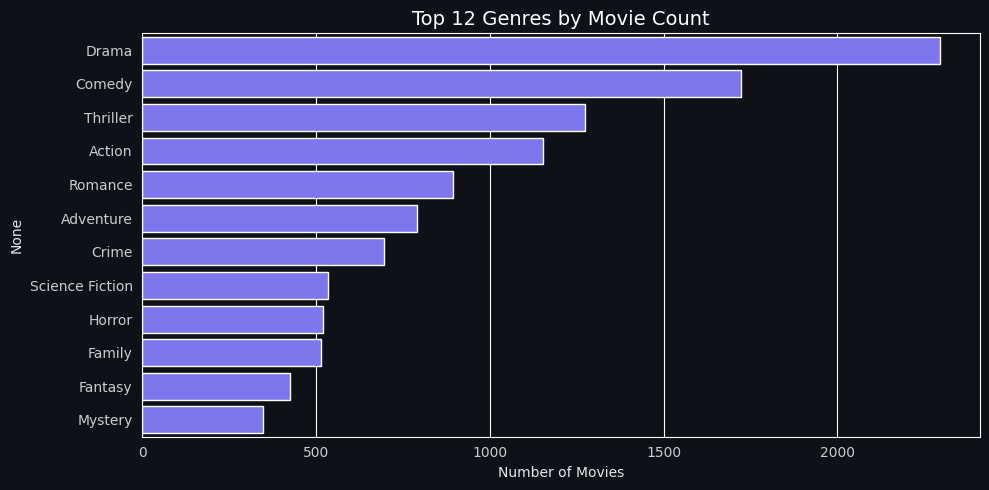

Insight: 'Drama' is the most common genre with 2296 movies, followed by 'Comedy' (1722) and 'Thriller' (1274). Together the top 3 genres account for 43.5% of all genre tags.


In [2]:
genre_counts = Counter(g for sub in df["genres_list"] for g in sub)
top_genres = pd.Series(genre_counts).sort_values(ascending=False).head(12)

plt.figure()
sns.barplot(x=top_genres.values, y=top_genres.index, color=ACCENT)
plt.title("Top 12 Genres by Movie Count", color="white", fontsize=14)
plt.xlabel("Number of Movies")
plt.tight_layout()
plt.savefig("../screenshots/eda_top_genres.png", dpi=110, facecolor="#0e1117")
plt.show()

print(f"Insight: '{top_genres.index[0]}' is the most common genre with {top_genres.iloc[0]} movies, "
      f"followed by '{top_genres.index[1]}' ({top_genres.iloc[1]}) and '{top_genres.index[2]}' "
      f"({top_genres.iloc[2]}). Together the top 3 genres account for "
      f"{round(top_genres.iloc[:3].sum() / sum(genre_counts.values()) * 100, 1)}% of all genre tags.")


## 2. Most Frequent Actors

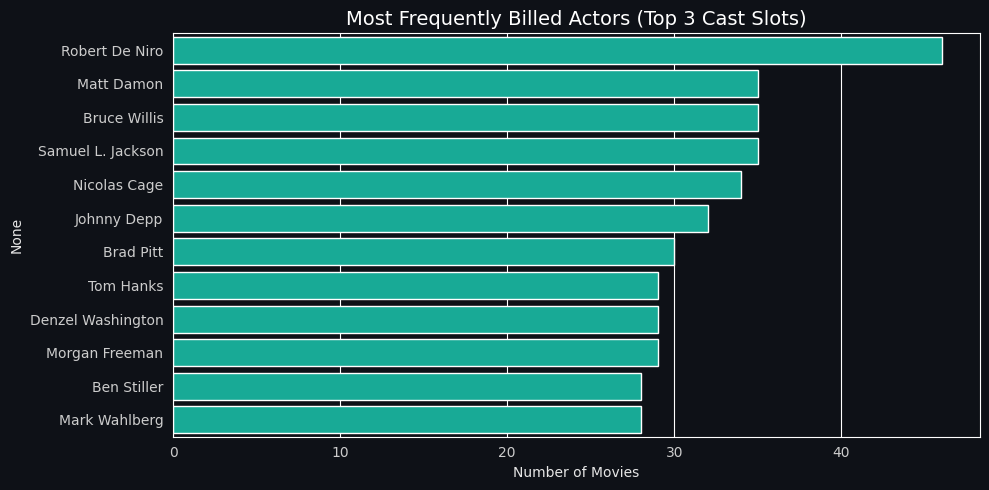

Insight: Robert De Niro appears in the top-3 billing of 46 movies in this dataset, the highest of any actor — a useful signal for the recommender's cast-overlap feature.


In [3]:
actor_counts = Counter(a for sub in df["cast_list"] for a in sub)
top_actors = pd.Series(actor_counts).sort_values(ascending=False).head(12)

plt.figure()
sns.barplot(x=top_actors.values, y=top_actors.index, color="#00C2A8")
plt.title("Most Frequently Billed Actors (Top 3 Cast Slots)", color="white", fontsize=14)
plt.xlabel("Number of Movies")
plt.tight_layout()
plt.savefig("../screenshots/eda_top_actors.png", dpi=110, facecolor="#0e1117")
plt.show()

print(f"Insight: {top_actors.index[0]} appears in the top-3 billing of {top_actors.iloc[0]} movies in "
      f"this dataset, the highest of any actor — a useful signal for the recommender's cast-overlap feature.")


## 3. Most Frequent Directors

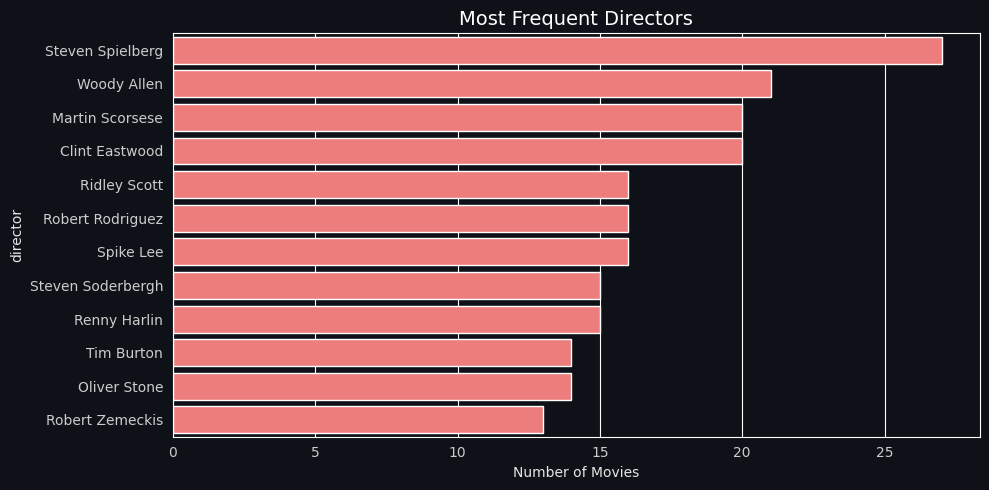

Insight: Steven Spielberg directed the most movies in the dataset (27), giving the recommender meaningful director-based signal for their filmography in particular.


In [4]:
director_counts = df[df["director"] != ""]["director"].value_counts().head(12)

plt.figure()
sns.barplot(x=director_counts.values, y=director_counts.index, color="#FF6B6B")
plt.title("Most Frequent Directors", color="white", fontsize=14)
plt.xlabel("Number of Movies")
plt.tight_layout()
plt.savefig("../screenshots/eda_top_directors.png", dpi=110, facecolor="#0e1117")
plt.show()

print(f"Insight: {director_counts.index[0]} directed the most movies in the dataset "
      f"({director_counts.iloc[0]}), giving the recommender meaningful director-based signal for "
      f"their filmography in particular.")


## 4. Movie Rating Distribution

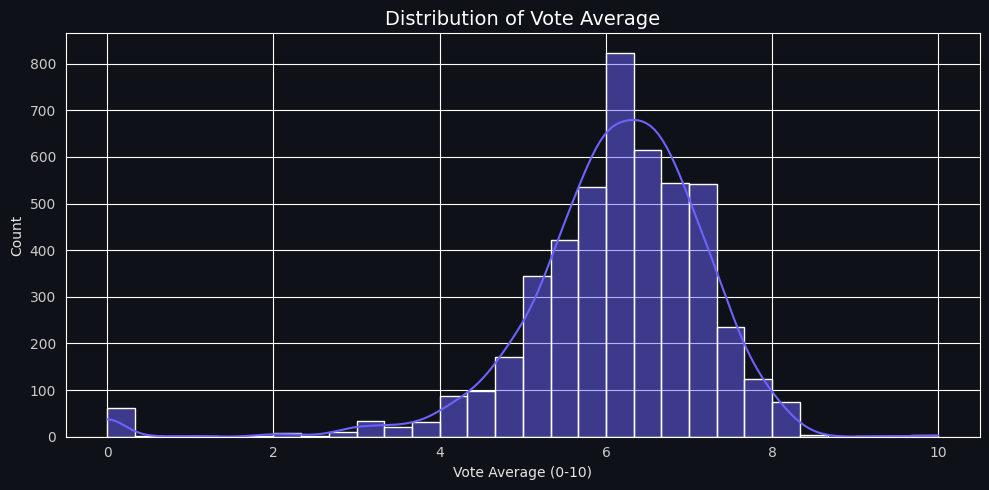

Insight: Ratings are roughly bell-shaped and centered around 6.09, with a median of 6.20. Only 61 movies have a vote_average of exactly 0, almost always because they received very few or no votes rather than being genuinely rated zero.


In [5]:
plt.figure()
sns.histplot(df["vote_average"], bins=30, kde=True, color=ACCENT)
plt.title("Distribution of Vote Average", color="white", fontsize=14)
plt.xlabel("Vote Average (0-10)")
plt.tight_layout()
plt.savefig("../screenshots/eda_rating_distribution.png", dpi=110, facecolor="#0e1117")
plt.show()

print(f"Insight: Ratings are roughly bell-shaped and centered around {df['vote_average'].mean():.2f}, "
      f"with a median of {df['vote_average'].median():.2f}. Only "
      f"{(df['vote_average'] == 0).sum()} movies have a vote_average of exactly 0, almost always "
      f"because they received very few or no votes rather than being genuinely rated zero.")


## 5. Release Year Trends

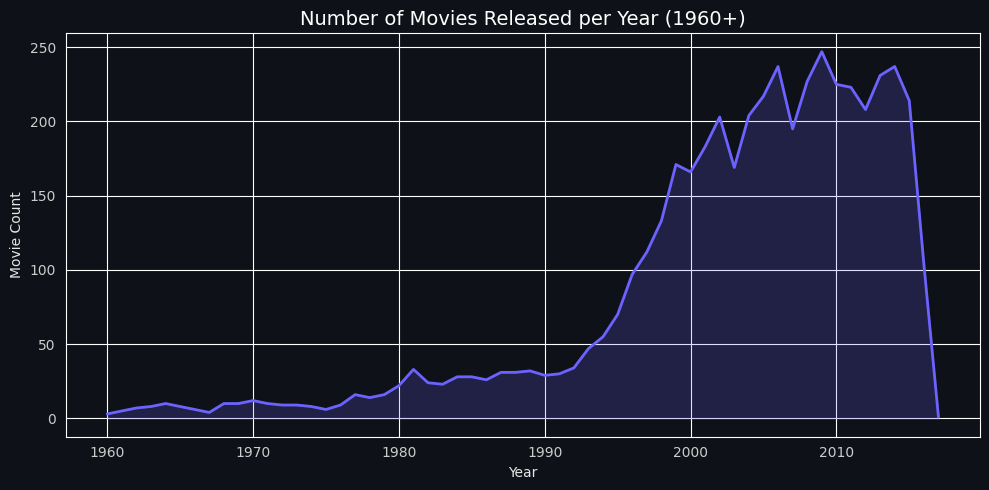

Insight: Movie output rises sharply after the 1990s, peaking in 2009 with 247 releases in this dataset — consistent with the well-documented industry-wide boom in mid-budget and franchise filmmaking through the 2000s-2010s.


In [6]:
yearly = df.dropna(subset=["release_year"]).groupby("release_year").size()
yearly = yearly[yearly.index >= 1960]

plt.figure()
plt.plot(yearly.index, yearly.values, color=ACCENT, linewidth=2)
plt.fill_between(yearly.index, yearly.values, color=ACCENT, alpha=0.2)
plt.title("Number of Movies Released per Year (1960+)", color="white", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Movie Count")
plt.tight_layout()
plt.savefig("../screenshots/eda_release_year_trend.png", dpi=110, facecolor="#0e1117")
plt.show()

peak_year = yearly.idxmax()
print(f"Insight: Movie output rises sharply after the 1990s, peaking in {int(peak_year)} with "
      f"{yearly.max()} releases in this dataset — consistent with the well-documented industry-wide "
      f"boom in mid-budget and franchise filmmaking through the 2000s-2010s.")


## 6. Most Popular Movies (by TMDB popularity score)

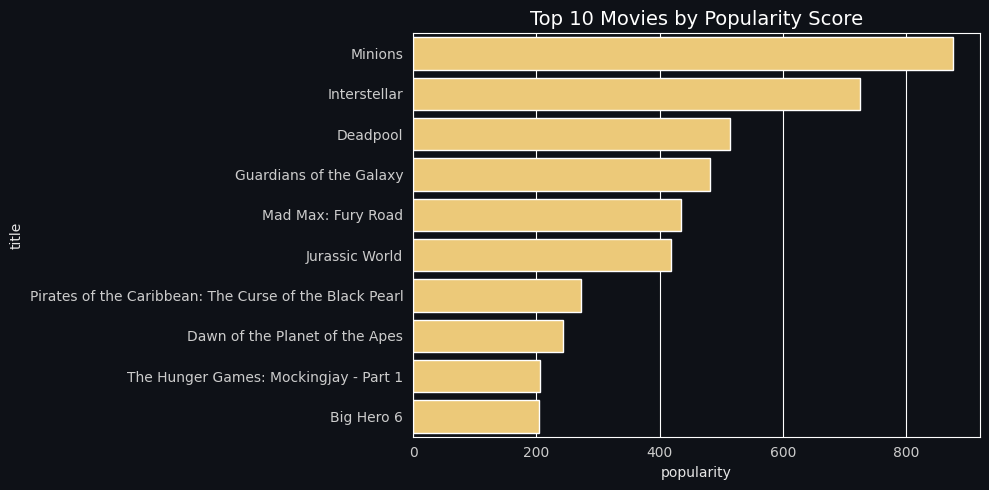

,title,popularity,vote_average
546,Minions,875.581305,6.4
95,Interstellar,724.247784,8.1
788,Deadpool,514.569956,7.4
94,Guardians of the Galaxy,481.098624,7.9
127,Mad Max: Fury Road,434.278564,7.2
28,Jurassic World,418.708552,6.5
199,Pirates of the Caribbean: The Curse of the Bla...,271.972889,7.5
82,Dawn of the Planet of the Apes,243.791743,7.3
200,The Hunger Games: Mockingjay - Part 1,206.227151,6.6
88,Big Hero 6,203.734590,7.8


In [7]:
top_popular = df.nlargest(10, "popularity")[["title", "popularity", "vote_average"]]

plt.figure()
sns.barplot(x="popularity", y="title", data=top_popular, color="#FFD166")
plt.title("Top 10 Movies by Popularity Score", color="white", fontsize=14)
plt.tight_layout()
plt.savefig("../screenshots/eda_top_popular.png", dpi=110, facecolor="#0e1117")
plt.show()

top_popular


## 7. Vote Average vs. Vote Count

An interactive Plotly scatter — renders inline in Jupyter/Colab; view the chart in a live notebook session for hover details.

In [8]:
sample = df[df["vote_count"] > 50]
fig = px.scatter(
    sample, x="vote_count", y="vote_average", size="popularity", color="vote_average",
    hover_name="title", color_continuous_scale="Viridis", opacity=0.7,
    title="Vote Average vs. Vote Count (movies with 50+ votes)",
)
fig.update_layout(template="plotly_dark", height=500)
fig.show()

corr = sample["vote_count"].corr(sample["vote_average"])
print(f"Insight: vote_count and vote_average have a correlation of {corr:.2f} — movies that attract "
      f"more votes tend to skew slightly better-rated, but the relationship is weak, meaning popularity "
      f"and quality are fairly independent signals worth keeping separate in the app's ranking logic.")


Insight: vote_count and vote_average have a correlation of 0.36 — movies that attract more votes tend to skew slightly better-rated, but the relationship is weak, meaning popularity and quality are fairly independent signals worth keeping separate in the app's ranking logic.


## 8. Runtime Analysis

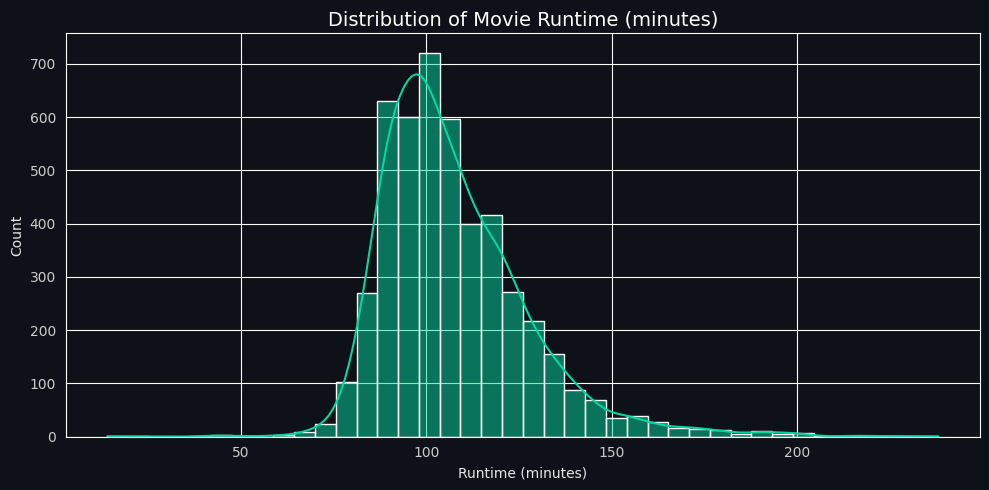

Insight: Median runtime is 104 minutes, with the large majority of films falling between 90 and 130 minutes — the conventional theatrical-release sweet spot.


In [9]:
runtime = df[(df["runtime"] > 0) & (df["runtime"] < 240)]["runtime"]

plt.figure()
sns.histplot(runtime, bins=40, color="#06D6A0", kde=True)
plt.title("Distribution of Movie Runtime (minutes)", color="white", fontsize=14)
plt.xlabel("Runtime (minutes)")
plt.tight_layout()
plt.savefig("../screenshots/eda_runtime_distribution.png", dpi=110, facecolor="#0e1117")
plt.show()

print(f"Insight: Median runtime is {runtime.median():.0f} minutes, with the large majority of films "
      f"falling between 90 and 130 minutes — the conventional theatrical-release sweet spot.")


## Summary

- Genre tags are dominated by a small set of mainstream genres, which the content-based model will
  need to weight carefully so niche genres aren't drowned out.
- A handful of actors and directors appear repeatedly — useful, high-signal features for similarity.
- Ratings cluster tightly around the mid-6s; vote count and rating are only weakly correlated.
- Movie output, runtime, and popularity all show clear, expected industry patterns, confirming the
  dataset is clean and ready for feature engineering.